# Canada Food CPI — CFPR Replica Experiment

**Core question:** of the methods evaluated here, which one should we trust to
produce the per-category forecast for the next Canada's Food Price Report?

This notebook runs a multi-predictor backtest against the canonical CFPR spec
(annual July origins 2009–2024, 12-step trajectory, all 9 StatCan food
sub-indices) and answers that question via per-category model selection on CRPS
and MAPE.

**What's here:**

1. Data overview — nine food CPI sub-indices at a glance.
2. Spec + predictors — loaded from YAML; backtest results cached on disk.
3. Qualitative check — trajectory fans and avg/avg YoY grid.
4. Model selection — CRPS and MAPE per category; per-category winner table.
5. Protected eval — budget-enforced holdout (commented out; spend deliberately).


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.
- `reference_specs/food_cpi/food_cpi_cfpr_{backtest,eval}.yaml` are the specs.

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.evaluation.eval import EvalTracker
from aieng.forecasting.methods import DartsAutoARIMAPredictor, LastValuePredictor
from food_price_forecasting.analysis import compute_ape_long, compute_avgyoy, compute_mape, summarize_crps
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service
from food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_food_cpi_small_multiples,
    plot_mape_by_category,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
EVAL_RUNS_PATH = ROOT / "data" / "eval_runs.yaml"
SPECS_DIR = ROOT / "reference_specs" / "food_cpi"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

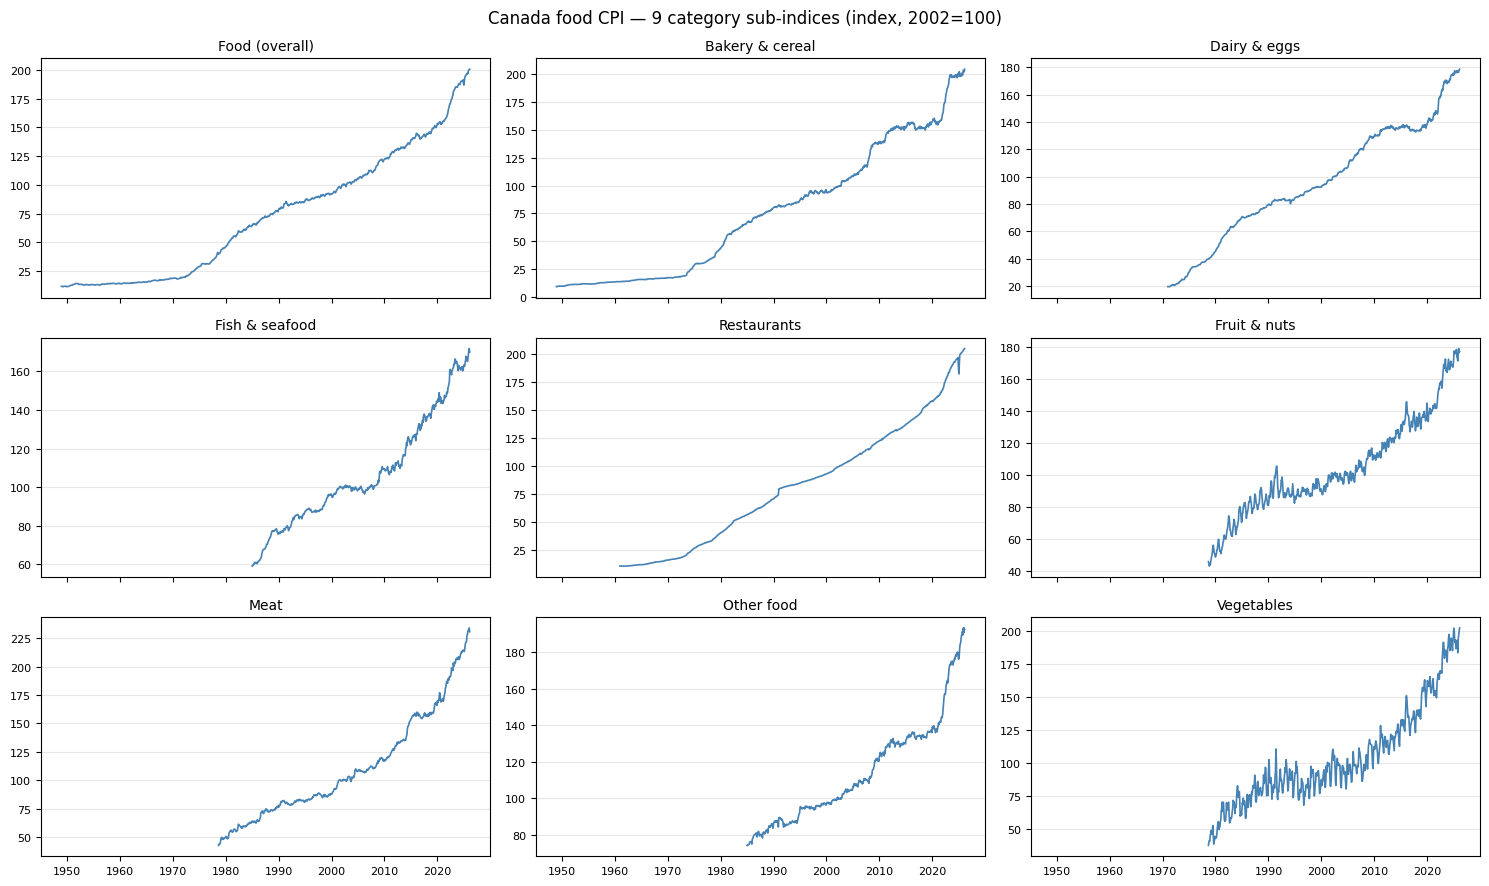

In [2]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The canonical CFPR task

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

In [3]:
with (SPECS_DIR / "food_cpi_cfpr_backtest.yaml").open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_cfpr_backtest)
  description: CFPR replica backtest: 9 Canadian food CPI sub-indices, annual July origins 2018-2024, 12-step trajectory (horizons 6-17) spanning Jan-Dec of the following calendar year.  Supports computation of the canonical average-over-average YoY CPI change that the Canada's Food Price Report publishes each year.  Open resource — run freely.
  start:       2018-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       9

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      M

---
## 4. Predictors

Three predictors, each implementing the same `Predictor` API against the same
spec.  Extend the `predictors` list or swap in your own subclass to run it
through the full evaluation loop.

- `LastValuePredictor` — repeats the last observed value with a fixed narrow
  spread.  Cheap, zero-configuration, hard to beat on very short horizons.
- `DartsAutoARIMAPredictor` — auto-ARIMA per origin with probabilistic output.
  Runs in seconds on a laptop for the 9-task spec.
- `ContinuousLLMPredictor` — direct numerical prompt (Gruver / CiK style),
  sample-based with empirical quantiles.  Requires an API key in the
  environment (`GEMINI_API_KEY`, `OPENAI_API_KEY`, or `ANTHROPIC_API_KEY`);
  results are cached after the first run.


In [ ]:
import pandas as pd
from aieng.forecasting.methods import (
    ContinuousLLMPredictor,
    ContinuousLLMPredictorConfig,
)


gemini_2_5_flash_lite_predictor = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-2.5-flash-lite", n_samples=3)
)
gemini_3_flash_predictor = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-3-flash-preview", n_samples=3)
)
# gemini_3_1_flash_lite_predictor = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3.1-flash-lite", n_samples=1))
# gemini_3_1_pro_predictor = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3.1-pro-preview", n_samples=1))

all_predictors = [
    LastValuePredictor(),
    DartsAutoARIMAPredictor(),
    gemini_2_5_flash_lite_predictor,
    gemini_3_flash_predictor,
    # gemini_3_1_flash_lite_predictor,
    # gemini_3_1_pro_predictor,
]

PREDICTOR_COLORS: dict[str, str] = {
    "last_value_naive": "#7f7f7f",
    "darts_autoarima": "#1f77b4",
    gemini_2_5_flash_lite_predictor.predictor_id: "#d62728",
    gemini_3_flash_predictor.predictor_id: "#9467bd",
    # gemini_3_1_flash_lite_predictor.predictor_id: "#2ca02c",
    # gemini_3_1_pro_predictor.predictor_id: "#ff7f0e",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

  last_value_naive
  darts_autoarima
  llmp_continuous[gemini/gemini-2.5-flash-lite]
  llmp_continuous[gemini/gemini-3-flash-preview]


---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on
subsequent runs.  Pass `force_refresh=True` to re-run a predictor from scratch.

All three predictors run against the same `food_cpi_cfpr_backtest` spec.
`ContinuousLLMPredictor` makes API calls on a first run (~144 calls at
`n_samples=3`); subsequent runs are free from cache.


In [5]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_crps:.4f}  ({len(result.predictions)} preds)")

Running last_value_naive ...
  food_cpi_overall_cfpr                       mean CRPS = 4.3958  (192 preds)
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.8276  (192 preds)
  food_cpi_dairy_eggs_cfpr                    mean CRPS = 3.5891  (192 preds)
  food_cpi_fish_seafood_cfpr                  mean CRPS = 3.6151  (192 preds)
  food_cpi_restaurants_cfpr                   mean CRPS = 5.2771  (192 preds)
  food_cpi_fruit_preparations_nuts_cfpr       mean CRPS = 4.6682  (192 preds)
  food_cpi_meat_cfpr                          mean CRPS = 6.8464  (192 preds)
  food_cpi_other_food_cfpr                    mean CRPS = 4.5427  (192 preds)
  food_cpi_vegetables_cfpr                    mean CRPS = 7.2313  (192 preds)
Running darts_autoarima ...
  food_cpi_overall_cfpr                       mean CRPS = 2.5160  (192 preds)
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.8202  (192 preds)
  food_cpi_dairy_eggs_cfpr                    mean CRPS = 2.5569  (192 preds)
  food_

---
## 6. Trajectories — overall food CPI

For the overall Canadian food CPI, show the three most recent origins with each
predictor's 12-step trajectory fan.  Solid black is observed history, dashed
black is the Y+1 actuals where available, fans are the predictor's 90%/50%
intervals with the median in colour.

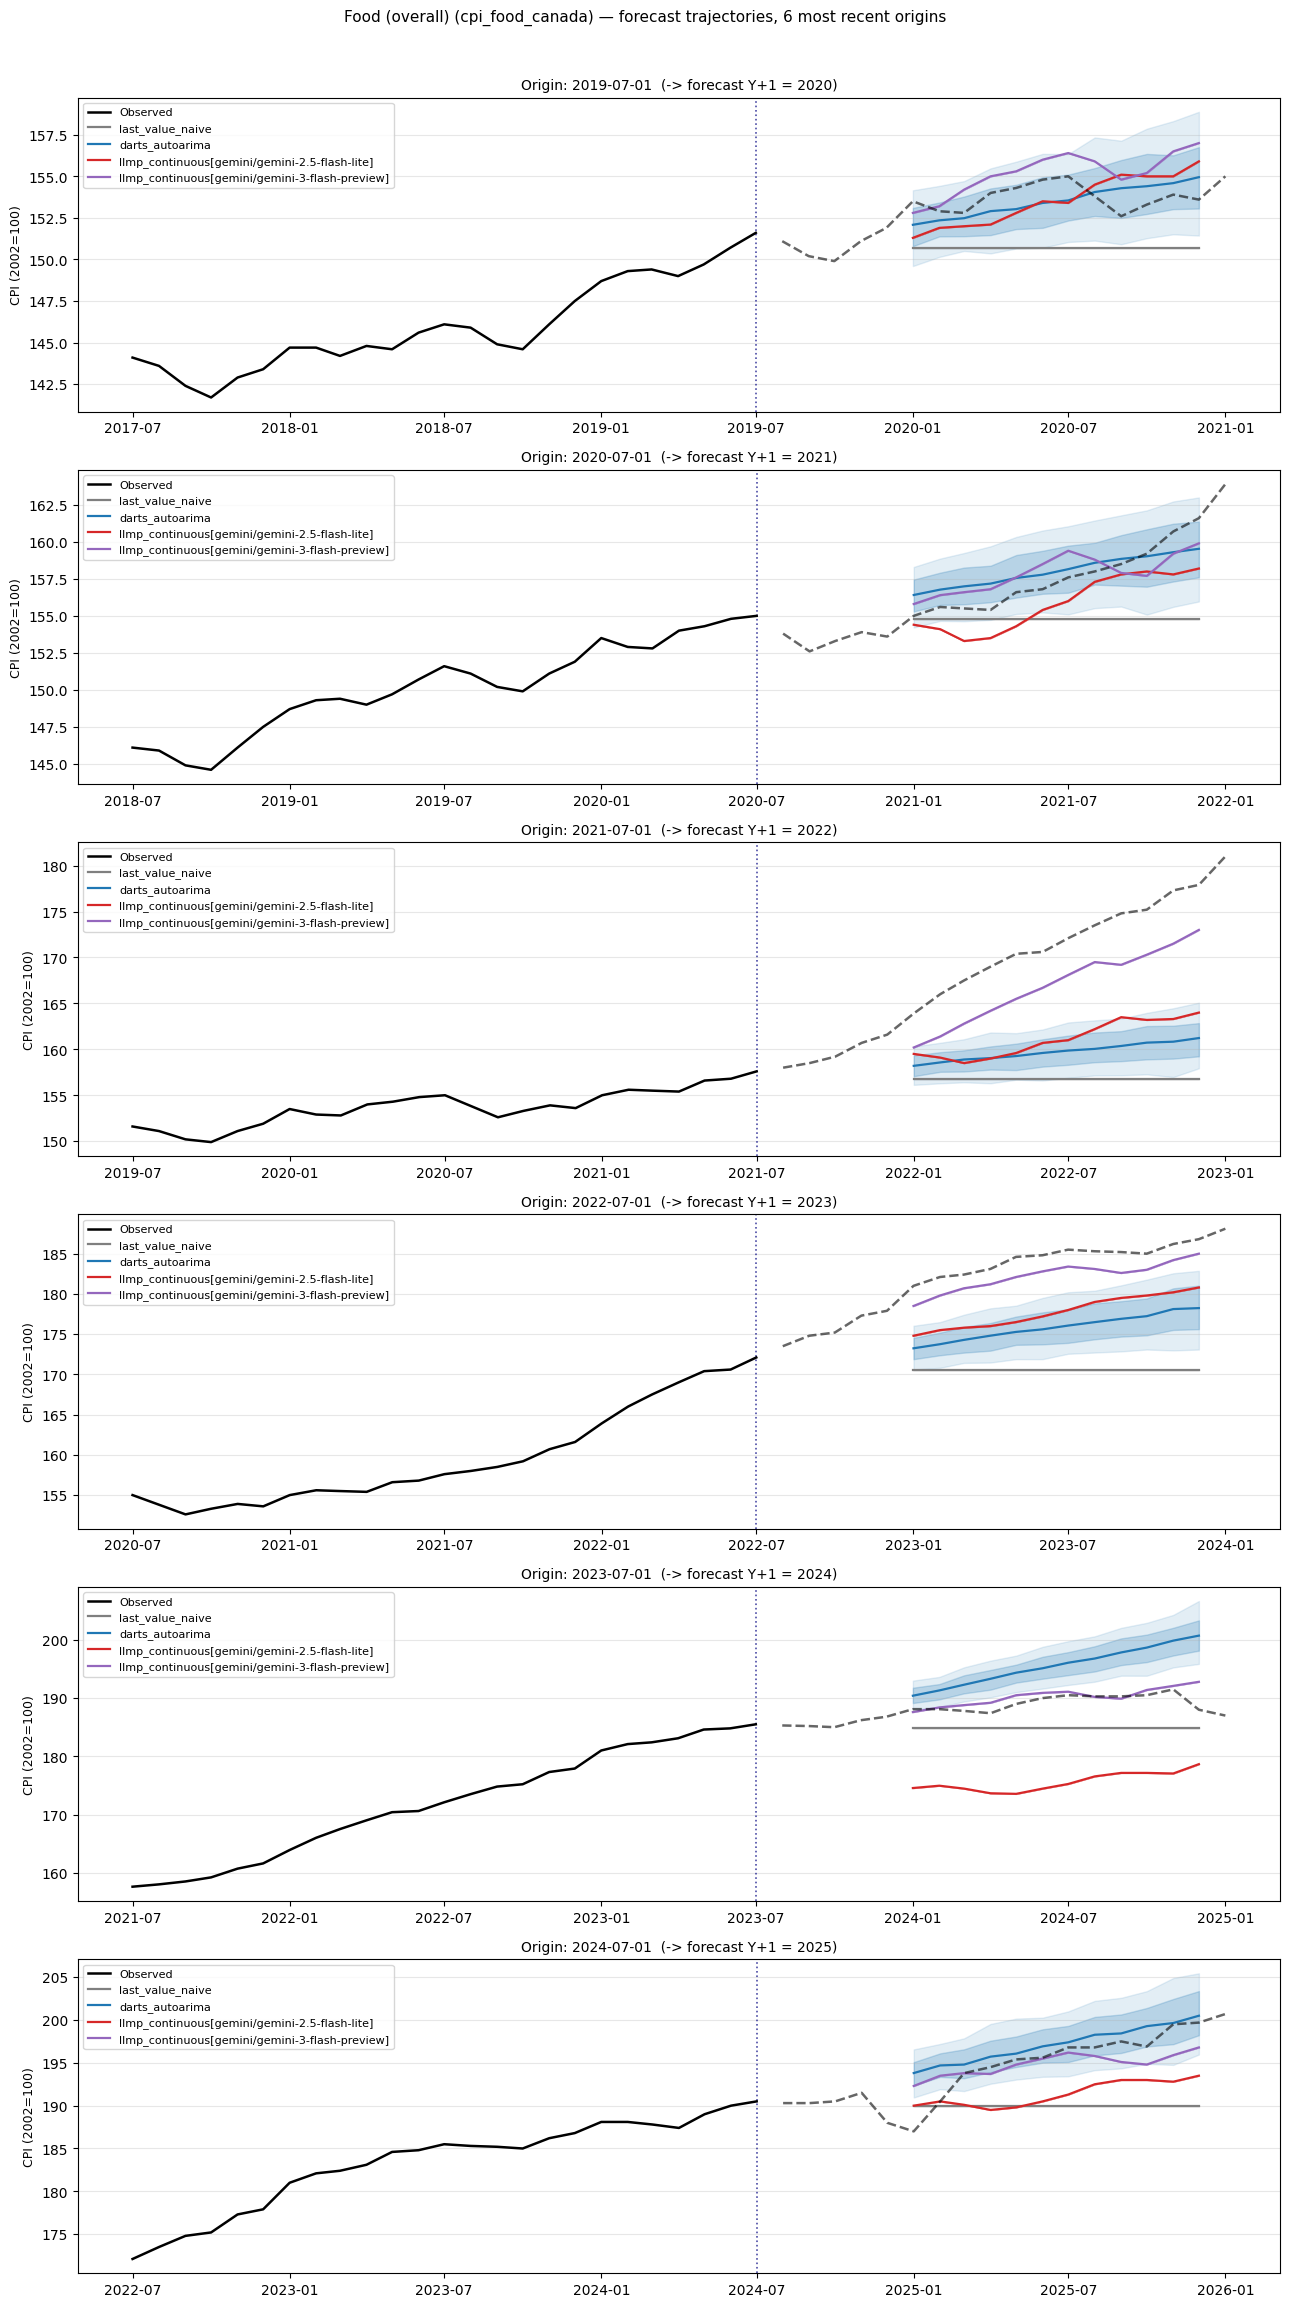

In [6]:
FOCAL_TASK = "food_cpi_overall_cfpr"
FOCAL_SERIES = "cpi_food_canada"

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 7. Avg/avg YoY — all 9 categories

The headline CFPR metric: for each July origin, mean predicted CPI for year Y+1
divided by mean observed CPI for year Y, minus 1.  Actual realised YoY (solid
black) is the out-of-sample truth for every completed year.

**Note on the 2022 spike:** LLMP with `reasoning_effort="disable"` anchors its
extrapolation on the *current level* rather than the *rate of change*, so it
tends to underestimate carry-through during a mid-surge origin.  This is a
known limitation of level-domain direct prompting (Gruver / CiK), not a
data-feeding issue.


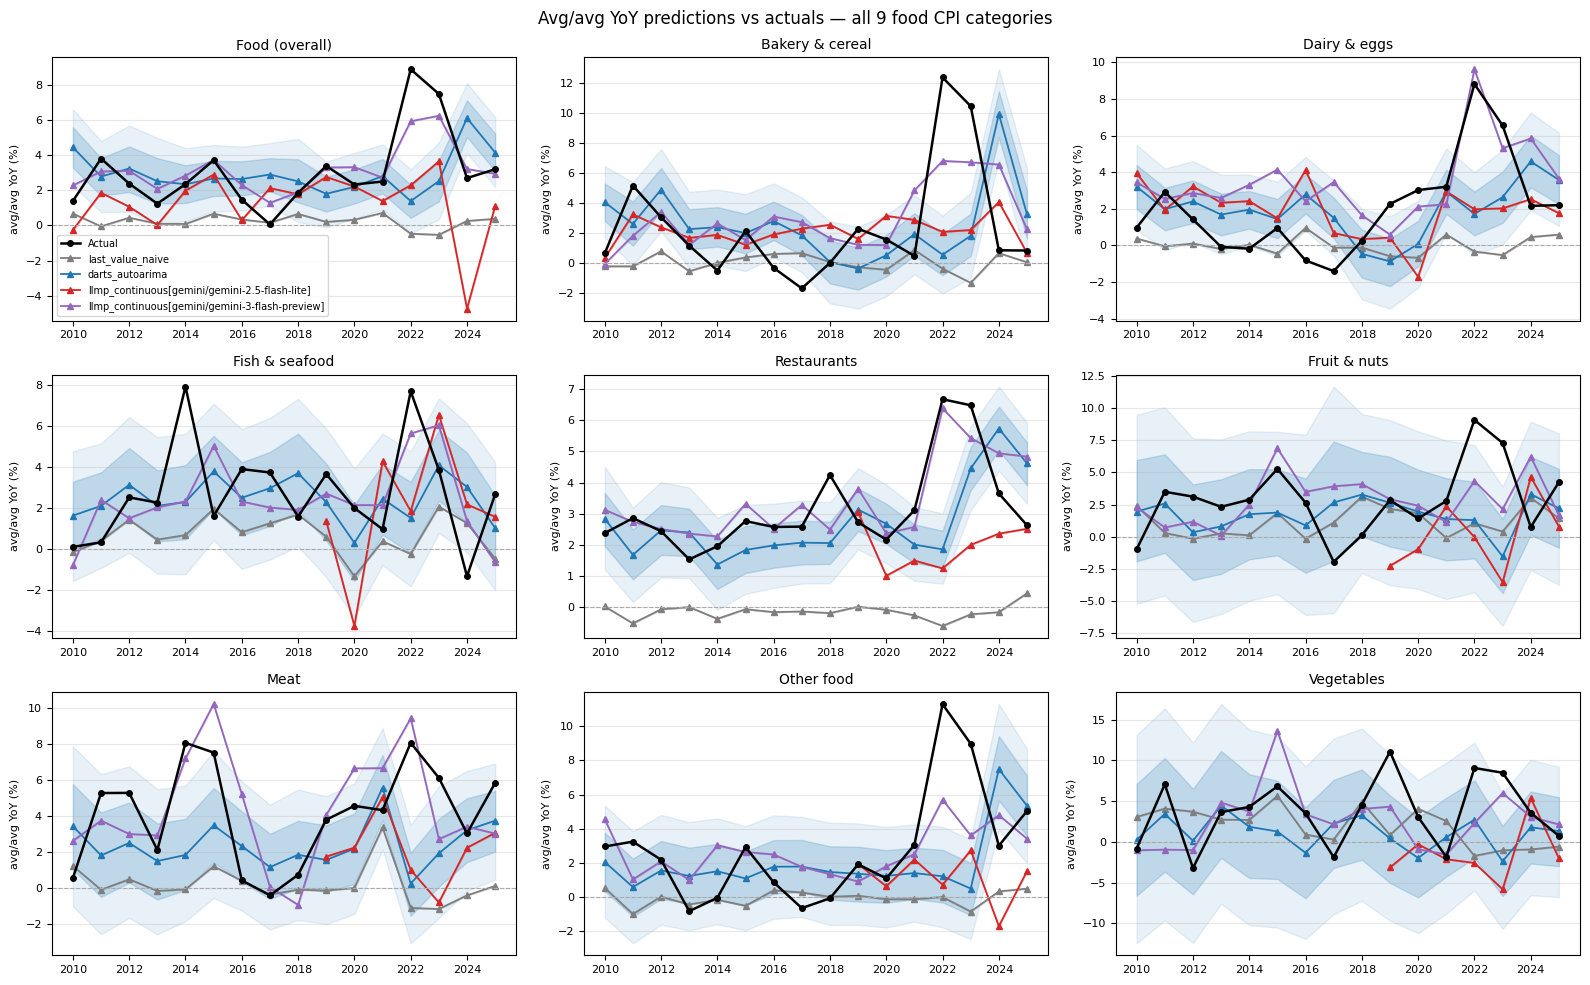

In [7]:
from datetime import datetime, timezone


yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 8. Model selection

### 8.1 CRPS per category

Lower is better.  The `MEAN` row is the across-category average — useful
context, but the per-category rows are the basis for model selection.

In [8]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

predictor_id                           darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-2.5-flash-lite]  llmp_continuous[gemini/gemini-3-flash-preview]
task_id                                                                                                                                                                
food_cpi_bakery_cereal_cfpr                   4.820200          4.827600                                       4.428800                                        4.249000
food_cpi_dairy_eggs_cfpr                      2.556900          3.589100                                       3.492700                                        3.030200
food_cpi_fish_seafood_cfpr                    2.249900          3.615100                                       5.245400                                        2.721400
food_cpi_fruit_preparations_nuts_cfpr         3.394600          4.668200                                       7.892500                                        4

### 8.2 MAPE per category

Median-accuracy sanity check (CRPS is the primary selection metric).  One panel
per sub-index; each box spans the distribution of per-prediction absolute
percentage errors across all backtest origins and horizons.

predictor_id                           darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-2.5-flash-lite]  llmp_continuous[gemini/gemini-3-flash-preview]
task_id                                                                                                                                                                
food_cpi_bakery_cereal_cfpr                      3.419             2.827                                          2.597                                           2.538
food_cpi_dairy_eggs_cfpr                         2.287             2.368                                          2.405                                           2.122
food_cpi_fish_seafood_cfpr                       2.185             2.558                                          3.410                                           1.979
food_cpi_fruit_preparations_nuts_cfpr            3.196             3.298                                          4.983                                         

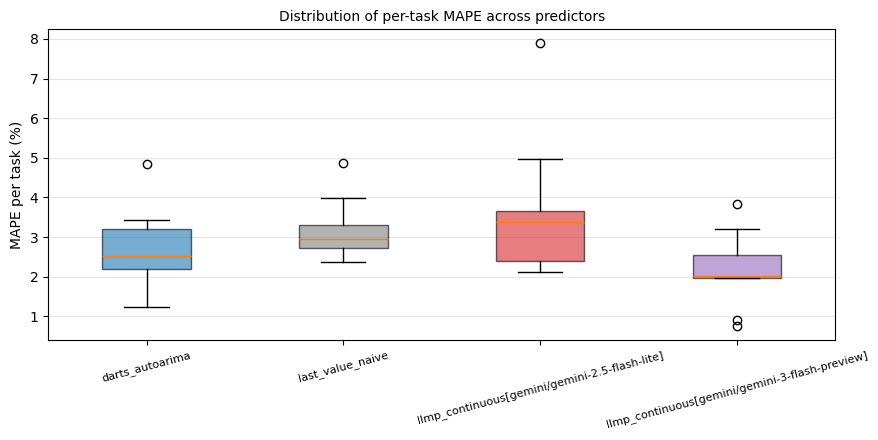

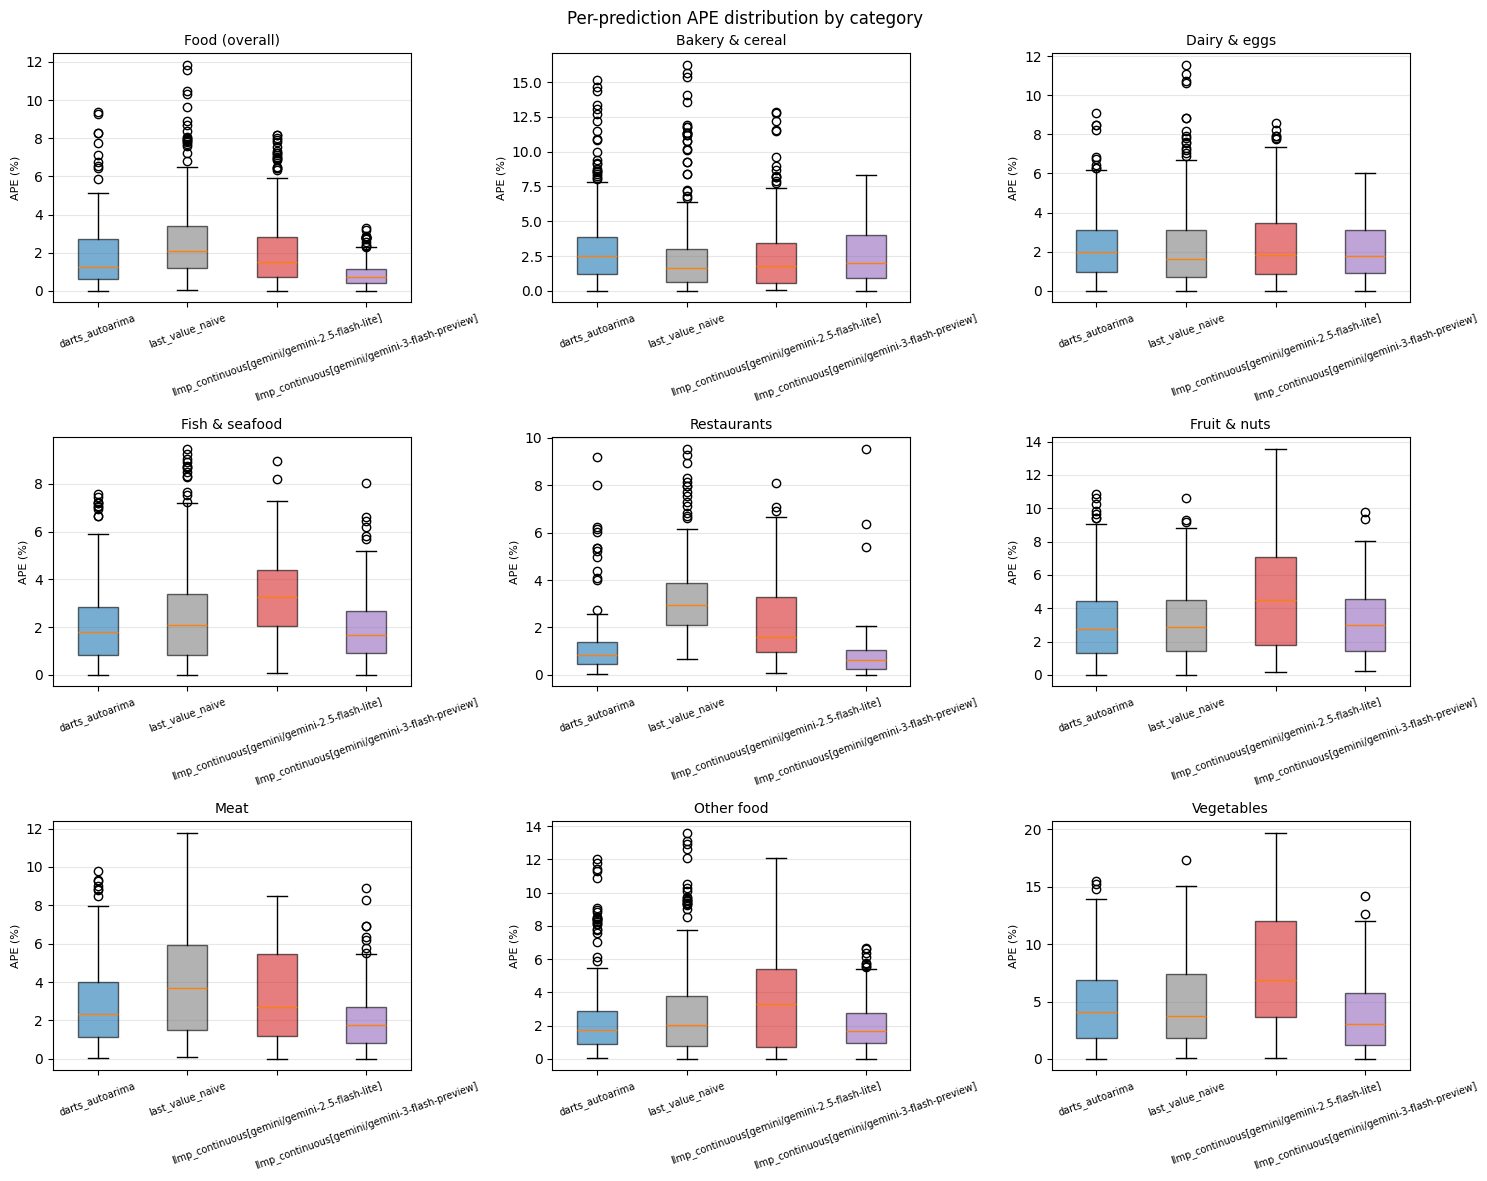

In [10]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

ape_long = compute_ape_long(results_by_predictor, data_service=svc)
fig, _ = plot_mape_by_category(ape_long, task_to_category=task_to_category, colors=PREDICTOR_COLORS)
plt.show()

---
## 9. Backtest-average avg/avg YoY — headline table

Model selection is done **per category**: for each food CPI sub-index the
predictor with the lowest mean CRPS over all backtest origins and horizons for
that category is selected independently.  The table below shows each
category's best predictor and its avg/avg YoY central estimate and uncertainty
band averaged across the full backtest window.

In [11]:
# Best predictor per category, selected by that category's own mean CRPS.
best_pid_by_task: dict[str, str] = crps_board.drop(index="MEAN").idxmin(axis=1).to_dict()
print("Best predictor by category (mean CRPS over full backtest window):")
for task_id, pid in best_pid_by_task.items():
    category = CATEGORY_LABELS.get(task_to_category[task_id], task_id)
    print(f"  {category:<40s} {pid}")

rows: list[dict[str, object]] = []
for task_id, pid in best_pid_by_task.items():
    yoy_df = yoy_by_predictor_by_task[pid].get(task_id)
    if yoy_df is None or yoy_df.empty:
        continue
    avg = yoy_df[["yoy_median", "yoy_q05", "yoy_q25", "yoy_q75", "yoy_q95", "actual_yoy"]].mean()
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "best_predictor": pid,
            "median_yoy_%": round(avg["yoy_median"] * 100, 2),
            "q05_%": round(avg["yoy_q05"] * 100, 2),
            "q25_%": round(avg["yoy_q25"] * 100, 2),
            "q75_%": round(avg["yoy_q75"] * 100, 2),
            "q95_%": round(avg["yoy_q95"] * 100, 2),
            "actual_yoy_%": round(avg["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print()
print(headline.to_string())

Best predictor by category (mean CRPS over full backtest window):
  Bakery & cereal                          llmp_continuous[gemini/gemini-3-flash-preview]
  Dairy & eggs                             darts_autoarima
  Fish & seafood                           darts_autoarima
  Fruit & nuts                             darts_autoarima
  Meat                                     llmp_continuous[gemini/gemini-3-flash-preview]
  Other food                               llmp_continuous[gemini/gemini-3-flash-preview]
  Food (overall)                           llmp_continuous[gemini/gemini-3-flash-preview]
  Restaurants                              llmp_continuous[gemini/gemini-3-flash-preview]
  Vegetables                               darts_autoarima

                                                 best_predictor  median_yoy_%  q05_%  q25_%  q75_%  q95_%  actual_yoy_%
category                                                                                                               
Bakery 

---
## 10. Protected evaluation

`EvalTracker` enforces `max_runs` from the YAML spec against a shared
`data/eval_runs.yaml` file.  Run this only when you believe the predictor
is ready for a final assessment — each call spends one of your five runs.

In [12]:
with (SPECS_DIR / "food_cpi_cfpr_eval.yaml").open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

print(describe_spec(eval_spec, data_service=svc))

tracker = EvalTracker(EVAL_RUNS_PATH)
used = tracker.runs_for(eval_spec.spec_id)
print(f"\nBudget: {used} / {eval_spec.max_runs} runs used for spec '{eval_spec.spec_id}'.")

MultiTargetEvalSpec (spec_id=food_cpi_cfpr_eval)
  description: CFPR replica protected evaluation: 9 Canadian food CPI sub-indices, last 4 annual July origins 2021-2024, 12-step trajectory (horizons 6-17) spanning Jan-Dec of the following calendar year.  Budget: 5 multi_evaluate() calls per participant.
  start:       2021-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  max_runs:    5
  tasks:       9

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      MS

Task: food_cpi_bakery_cereal_cfpr
  description: Canada CPI Bakery and cereal p

In [13]:
# ── Uncomment to spend a run ──────────────────────────────────────────────────
# from aieng.forecasting.evaluation.eval import multi_evaluate
#
# best_predictor = next(p for p in predictors if p.predictor_id == best_pid)
# eval_results = multi_evaluate(
#     predictor=best_predictor,
#     spec=eval_spec,
#     data_service=svc,
#     tracker=tracker,
# )
# for task_id, r in eval_results.items():
#     print(f"  {task_id:42s}  mean CRPS = {r.mean_crps:.4f}  (run {r.run_number}/{eval_spec.max_runs})")